In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, matthews_corrcoef

In [ ]:
tickers = ["MSFT", "JPM", "XOM", "LLY", "AMZN"]
dfs = {}
for ticker in tickers:
  dfs[ticker] = yf.download(ticker, period="5y")
for ticker, df in dfs.items():
  df["Return"] = df["Close"].pct_change()
  df["5d_return"] = df["Close"].pct_change(periods=5)
  df["20d_return"] = df["Close"].pct_change(periods=20)
  df["20d_volitlity"] = df["Return"].rolling(20).std()
  ma20 = df['Close'].rolling(20).mean()
  df['ma_spread'] = (df['Close'] - ma20) / ma20
  gain = pd.Series(np.where(df["Return"] > 0, df["Return"], 0), index=df.index)
  loss = pd.Series(np.where(df["Return"] < 0, abs(df["Return"]), 0), index=df.index)
  avg_gain = gain.rolling(14).mean()
  avg_loss = loss.rolling(14).mean()
  rs = avg_gain / avg_loss
  df["RSI"] = 100 - (100 / (1 + rs))
  df["Classification"] = np.where(df["Return"].shift(-1) > 0, 1, 0)
  df.dropna(inplace=True)



dfs["MSFT"].columns
dfs["MSFT"]["ma_spread"].tail()
dfs["MSFT"]["Return"].tail()
dfs["MSFT"][["Return", "RSI"]].tail(10)
dfs["MSFT"]["Classification"].value_counts()

/tmp/ipykernel_11289/2228213691.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dfs[ticker] = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11289/2228213691.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dfs[ticker] = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11289/2228213691.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dfs[ticker] = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11289/2228213691.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dfs[ticker] = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_11289/2228213691.py:4: FutureWarning: YF.download

,count
Classification,
1,635
0,600


In [ ]:
splits = {}
for ticker, df in dfs.items():
  split = int(len(df) * 0.8)
  X = df[["Return", "5d_return", "20d_return", "20d_volitlity", "ma_spread", "RSI"]]
  y = df["Classification"]
  X_train, X_test = X.iloc[:split], X.iloc[split:]
  y_train, y_test = y.iloc[:split], y.iloc[split:]
  splits[ticker] = {"X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test}

models = {}
for ticker, df in dfs.items():
  model = RandomForestClassifier()
  model.fit(splits[ticker]["X_train"], splits[ticker]["y_train"])
  predictions = model.predict(splits[ticker]["X_test"])
  models[ticker] = {"model": model, "predictions": predictions}
  models[ticker]["f1"] = f1_score(splits[ticker]["y_test"], models[ticker]["predictions"])
  models[ticker]["mcc"] = matthews_corrcoef(splits[ticker]["y_test"], models[ticker]["predictions"])

for ticker in models:
    print(f"{ticker} — F1: {models[ticker]['f1']:.3f}, MCC: {models[ticker]['mcc']:.3f}")




MSFT — F1: 0.531, MCC: -0.018
JPM — F1: 0.563, MCC: 0.008
XOM — F1: 0.588, MCC: 0.053
LLY — F1: 0.485, MCC: -0.106
AMZN — F1: 0.514, MCC: 0.007


In [ ]:

for ticker in models:
  models[ticker]["Signal"] = pd.Series(np.where(models[ticker]["predictions"] == 1, 1, -1),index=splits[ticker]["X_test"].index)
  models[ticker]["Strategy_Return"] = models[ticker]["Signal"].shift(1) * splits[ticker]["X_test"]["Return"]
  models[ticker]["Cumulative_Return"] = (1 + models[ticker]["Strategy_Return"]).cumprod()
  models[ticker]["Sharpe"] = (models[ticker]["Strategy_Return"].mean() / models[ticker]["Strategy_Return"].std()) * np.sqrt(252)
  models[ticker]["Max_Drawdown"] = ((models[ticker]["Cumulative_Return"] - models[ticker]["Cumulative_Return"].cummax()) / models[ticker]["Cumulative_Return"].cummax()).min()

for ticker in models:
    print(f"{ticker} — Sharpe: {models[ticker]['Sharpe']:.3f}, Max DD: {models[ticker]['Max_Drawdown']:.3f}, Cum Return: {models[ticker]['Cumulative_Return'].iloc[-1]:.3f}")




MSFT — Sharpe: 0.740, Max DD: -0.129, Cum Return: 1.168
JPM — Sharpe: -0.837, Max DD: -0.320, Cum Return: 0.814
XOM — Sharpe: 1.319, Max DD: -0.117, Cum Return: 1.335
LLY — Sharpe: -1.499, Max DD: -0.493, Cum Return: 0.532
AMZN — Sharpe: 1.344, Max DD: -0.169, Cum Return: 1.428


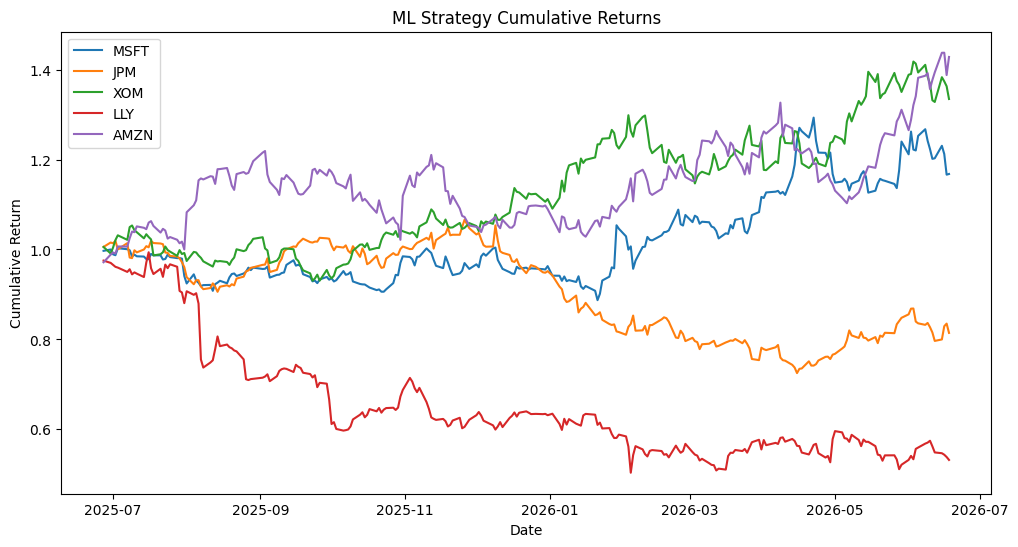

In [ ]:
plt.figure(figsize=(12, 6))
for ticker in models:
  plt.plot(models[ticker]["Cumulative_Return"], label=ticker)
plt.legend()
plt.title("ML Strategy Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.show()

In [ ]:
!pip install colab-xterm
%load_ext colabxterm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 2.6 MB/s eta 0:00:00


In [3]:
%xterm


Launching Xterm...

<IPython.core.display.Javascript object>